# Part 1: Retrieving Census Data via the API

In this notebook you will:
- Use the U.S. Census Bureau API to request ACS 5-year estimate data
- Store the response as a pandas DataFrame
- Clean the GEOID column so it is ready for spatial joins later
- Visualize the clean Census Data and Analyze it

**Before you begin:** If you haven't already, review the variable codes at  
https://api.census.gov/data/2023/acs/acs5/profile/variables.html  
Press **Ctrl+F** on that page to search for your variable of interest and note its code (e.g. `DP04_0058E`).

---

## 1.1 — Install and Import Libraries

In [1]:
# Standard libraries — install geopandas if running on Colab
# !pip install geopandas  # uncomment if needed

import requests
import json
import pandas as pd

## 1.2 — Download Census Data via the API

The function below interactively prompts you for:
- **Year** (2009–2023)
- **ACS type** (acs1 or acs5)
- **Variable codes** (comma-separated, e.g. `DP04_0058E,DP03_0062E`)
- **Geography level** (state, county, or tract)
- **State FIPS code** (e.g. `18` for Indiana; use `*` for all states)
- **Optional Census API key** (free at https://api.census.gov/data/key_signup.html)

The downloaded data is saved as a `.csv` file in your working directory.

In [2]:
def download_census_data():
    """Prompt the user for query parameters, call the Census API, and save results as CSV."""
    print("=== Census API Downloader — ACS Profile Data ===\n")

    # --- User inputs ---
    year = input("Enter year (2009–2023, default 2023): ").strip() or "2023"
    acs  = input("Enter ACS type (acs1 or acs5, default acs5): ").strip() or "acs5"

    variables_str = input("Enter variable codes separated by commas (e.g., DP04_0058E,DP03_0062E): ")
    variables = [v.strip() for v in variables_str.split(",") if v.strip()]

    # GEO_ID and NAME are always included so rows can be identified and joined later
    get_params = "NAME,GEO_ID"
    if variables:
        get_params += "," + ",".join(variables)

    level  = input("Enter geography level (state / county / tract): ").strip().lower()
    state  = input("Enter state FIPS code or * for all states (e.g. 18 for Indiana): ").strip() or "*"
    county = "*"
    tract  = "*"

    if level in ["county", "tract"]:
        county = input("Enter county FIPS code or * for all counties: ").strip() or "*"
    if level == "tract":
        tract = input("Enter tract code or * for all tracts: ").strip() or "*"

    key = input("Enter your Census API key (press Enter to skip): ").strip()

    # --- Build URL ---
    base_url = f"https://api.census.gov/data/{year}/acs/{acs}/profile"

    if level == "state":
        for_str = f"state:{state}"
        in_str  = ""
    elif level == "county":
        for_str = f"county:{county}"
        in_str  = f"state:{state}" if state != "*" else ""
    elif level == "tract":
        for_str = f"tract:{tract}"
        in_str  = f"state:{state} county:{county}"
    else:
        print("Invalid geography level. Please use state, county, or tract.")
        return

    url = f"{base_url}?get={get_params}&for={for_str}&descriptive=true"
    if in_str:
        url += f"&in={in_str}"
    if key:
        url += f"&key={key}"

    print(f"\nConstructed API URL:\n{url}\n")

    # --- Fetch and save ---
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()

        if not data or len(data) < 2:
            print("No data returned. Check your variable codes and geography inputs.")
            return

        df = pd.DataFrame(data[1:], columns=data[0])

        csv_filename = f"census_data_{year}_{acs}_{level}.csv"
        df.to_csv(csv_filename, index=False)
        print(f"Data saved as: {csv_filename}")
        print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
        print("\nPreview:")
        display(df.head())

    except requests.exceptions.RequestException as e:
        print(f"Network error: {e}")
    except json.JSONDecodeError:
        print("Could not parse API response. Check that your variable codes and parameters are correct.")
    except Exception as e:
        print(f"Unexpected error: {e}")

## 1.3 — Run the Downloader

#### **Important:** For this session stick with `TRACT` as the notebook is defaulted to run TRACTS rather than COUNTIES. Feel free to explore COUNTIES data upto Part 2, but if you want to continue beyond Part 2 then stick with TRACTS.

#### Feel Free to whatever state you like!
#### If you want to know what is the `FIPS` code of your state, see here: https://transition.fcc.gov/oet/info/maps/census/fips/fips.txt
#### The code below will ask for the FIPS code, make sure you know it for you preferred state!

In [3]:
download_census_data()

=== Census API Downloader — ACS Profile Data ===

Enter year (2009–2023, default 2023): 
Enter ACS type (acs1 or acs5, default acs5): 
Enter variable codes separated by commas (e.g., DP04_0058E,DP03_0062E): DP04_0058E
Enter geography level (state / county / tract): tract
Enter state FIPS code or * for all states (e.g. 18 for Indiana): 18
Enter county FIPS code or * for all counties: *
Enter tract code or * for all tracts: *
Enter your Census API key (press Enter to skip): 

Constructed API URL:
https://api.census.gov/data/2023/acs/acs5/profile?get=NAME,GEO_ID,DP04_0058E&for=tract:*&descriptive=true&in=state:18 county:*

Data saved as: census_data_2023_acs5_tract.csv
Shape: 1697 rows × 6 columns

Preview:


,NAME,GEO_ID,DP04_0058E,state,county,tract
0,Geographic Area Name,Geography,Estimate!!VEHICLES AVAILABLE!!Occupied housing...,State,County,Census Tract
1,Census Tract 301; Adams County; Indiana,1400000US18001030100,20,18,001,030100
2,Census Tract 302; Adams County; Indiana,1400000US18001030200,245,18,001,030200
3,Census Tract 303; Adams County; Indiana,1400000US18001030300,73,18,001,030300
4,Census Tract 304; Adams County; Indiana,1400000US18001030400,167,18,001,030400


#### **REMINDER:** Make sure to update the csv file name based on what appears in STEP 1.3 for the rest of the notebook.

## 1.4 — Load the Downloaded File into a DataFrame

Once the file has been saved, load it here for inspection.

In [5]:
# Update the filename below to match what was saved in 1.3
csv_filename = "census_data_2023_acs5_tract.csv"

df = pd.read_csv(csv_filename)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Shape: 1697 rows × 6 columns


,NAME,GEO_ID,DP04_0058E,state,county,tract
0,Geographic Area Name,Geography,Estimate!!VEHICLES AVAILABLE!!Occupied housing...,State,County,Census Tract
1,Census Tract 301; Adams County; Indiana,1400000US18001030100,20,18,001,030100
2,Census Tract 302; Adams County; Indiana,1400000US18001030200,245,18,001,030200
3,Census Tract 303; Adams County; Indiana,1400000US18001030300,73,18,001,030300
4,Census Tract 304; Adams County; Indiana,1400000US18001030400,167,18,001,030400


## 1.5 — Clean the GEOID Column

The raw `GEO_ID` field from the Census API looks like `1400000US18001`.  
For spatial joins with TIGER shapefiles, we need just the numeric suffix (e.g. `18001`).  
We extract that into a new `GEOID` column.

In [6]:
# Extract the numeric GEOID by splitting on 'US'
df["GEOID"] = df["GEO_ID"].str.split("US", n=1).str[1]

# Reorder so GEOID sits next to GEO_ID for easy inspection
cols = list(df.columns)
geo_id_idx = cols.index("GEO_ID")
cols.insert(geo_id_idx + 1, cols.pop(cols.index("GEOID")))
df = df[cols]

print("GEOID sample values:", df["GEOID"].head().tolist())
df.head()

GEOID sample values: [nan, '18001030100', '18001030200', '18001030300', '18001030400']


,NAME,GEO_ID,GEOID,DP04_0058E,state,county,tract
0,Geographic Area Name,Geography,NaN,Estimate!!VEHICLES AVAILABLE!!Occupied housing...,State,County,Census Tract
1,Census Tract 301; Adams County; Indiana,1400000US18001030100,18001030100,20,18,001,030100
2,Census Tract 302; Adams County; Indiana,1400000US18001030200,18001030200,245,18,001,030200
3,Census Tract 303; Adams County; Indiana,1400000US18001030300,18001030300,73,18,001,030300
4,Census Tract 304; Adams County; Indiana,1400000US18001030400,18001030400,167,18,001,030400


---
## Summary

You now have a clean DataFrame with:
- Census ACS data for your chosen variables and geography
- A `GEOID` column ready for spatial joining

**Next:** Continue to **Part 2** to explore the dataset structure, understand the variables, and inspect geographic coverage.

# Part 2: Exploring the Census Dataset

In this notebook you will:
- Inspect the structure of the downloaded ACS dataset
- Understand what each column represents
- Examine geographic coverage (states, counties, tracts)
- Identify data types, missing values, and value ranges

**Prerequisites:** Complete Part 1 and have a `census_data_*.csv` file in your working directory.

---

## 2.1 — Import Libraries and Load Data

#### Make SURE! to update the file name here. For our example we are running a county file for Indiana for estimated vehicles in occupied households

In [8]:
import pandas as pd

# Update this filename to match the file you saved in Part 1
csv_filename = "census_data_2023_acs5_tract.csv"

df = pd.read_csv(csv_filename)

# Re-derive GEOID if loading fresh (in case Part 1 wasn't run in this session)
if "GEOID" not in df.columns:
    df["GEOID"] = df["GEO_ID"].str.split("US", n=1).str[1]

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 1697 rows × 7 columns


,NAME,GEO_ID,DP04_0058E,state,county,tract,GEOID
0,Geographic Area Name,Geography,Estimate!!VEHICLES AVAILABLE!!Occupied housing...,State,County,Census Tract,NaN
1,Census Tract 301; Adams County; Indiana,1400000US18001030100,20,18,001,030100,18001030100
2,Census Tract 302; Adams County; Indiana,1400000US18001030200,245,18,001,030200,18001030200
3,Census Tract 303; Adams County; Indiana,1400000US18001030300,73,18,001,030300,18001030300
4,Census Tract 304; Adams County; Indiana,1400000US18001030400,167,18,001,030400,18001030400


## 2.2 — Column Overview

Let's see all column names, their data types, and how many non-null values each has.

In [9]:
# Full column list with dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1697 entries, 0 to 1696
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   NAME        1697 non-null   object
 1   GEO_ID      1697 non-null   object
 2   DP04_0058E  1697 non-null   object
 3   state       1697 non-null   object
 4   county      1697 non-null   object
 5   tract       1697 non-null   object
 6   GEOID       1696 non-null   object
dtypes: object(7)
memory usage: 92.9+ KB


In [10]:
# Quick summary of all columns
print("Columns in this dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>3}. {col}")

Columns in this dataset:
    1. NAME
    2. GEO_ID
    3. DP04_0058E
    4. state
    5. county
    6. tract
    7. GEOID


## 2.3 — Understanding the Variables

ACS Profile variable codes follow a consistent naming pattern:

| Part | Meaning | Example |
|------|---------|---------|
| `DP04` | Table identifier (housing) | `DP01`=demographics, `DP02`=social, `DP03`=economic, `DP04`=housing |
| `_0058` | Variable number within the table | Sequential within each table |
| `E` | Estimate | `E`=estimate, `M`=margin of error, `PE`=percent estimate, `PM`=percent margin |

Use the code below to list all numeric (estimate) columns in the dataset.

In [11]:
# Identify estimate columns (end in 'E') vs margin-of-error columns (end in 'M')
estimate_cols = [c for c in df.columns if c.endswith("E") and c not in ("NAME", "GEO_ID", "GEOID")]
moe_cols      = [c for c in df.columns if c.endswith("M")]

print(f"Estimate columns  : {len(estimate_cols)}")
print(f"Margin-of-error columns: {len(moe_cols)}")
print()
print("Estimate columns:", estimate_cols)

Estimate columns  : 1
Margin-of-error columns: 0

Estimate columns: ['DP04_0058E']


## 2.4 — Geographic Units

Let's examine what geographic units are present — states, counties, or tracts — and check coverage.

In [12]:
# How many unique geographic units?
print(f"Total rows           : {len(df)}")
print(f"Unique NAME values   : {df['NAME'].nunique()}")
print(f"Unique GEOID values  : {df['GEOID'].nunique()}")
print()

# Show a sample of geographic names
print("Sample geographic units:")
df["NAME"].head(10).to_frame()

Total rows           : 1697
Unique NAME values   : 1697
Unique GEOID values  : 1696

Sample geographic units:


,NAME
0,Geographic Area Name
1,Census Tract 301; Adams County; Indiana
2,Census Tract 302; Adams County; Indiana
3,Census Tract 303; Adams County; Indiana
4,Census Tract 304; Adams County; Indiana
5,Census Tract 305; Adams County; Indiana
6,Census Tract 306; Adams County; Indiana
7,Census Tract 307; Adams County; Indiana
8,Census Tract 1; Allen County; Indiana
9,Census Tract 3; Allen County; Indiana


In [13]:
# If the dataset is county-level, extract the state FIPS (first 2 digits of GEOID)
# and see how many counties per state
if "state" in df.columns:
    state_counts = df.groupby("state").size().reset_index(name="county_count")
    state_counts = state_counts.sort_values("county_count", ascending=False)
    print("Counties per state (top 10):")
    display(state_counts.head(10))
else:
    # Derive state code from GEOID if 'state' column not present
    df["state_fips"] = df["GEOID"].str[:2]
    state_counts = df.groupby("state_fips").size().reset_index(name="unit_count")
    print("Geographic units per state FIPS (top 10):")
    display(state_counts.sort_values("unit_count", ascending=False).head(10))

Counties per state (top 10):


,state,county_count
0,18,1696
1,State,1


## 2.5 — Inspecting Variable Values

Let's look at the distribution and range of your variable columns.

In [14]:
# Convert estimate columns to numeric (Census API returns everything as strings)
for col in estimate_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Summary statistics for all estimate columns
df[estimate_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
DP04_0058E,1696.0,98.07,104.75,0.0,26.0,67.0,134.0,816.0


In [15]:
# Check for missing or negative values
# (Negative values like -666666666 are Census placeholders for 'not available')
CENSUS_NULL = -666666666

for col in estimate_cols:
    nulls = df[col].isna().sum()
    placeholders = (df[col] == CENSUS_NULL).sum()
    if nulls > 0 or placeholders > 0:
        print(f"{col}: {nulls} NaN, {placeholders} placeholder (-666666666) values")

print("\nCheck complete.")

DP04_0058E: 1 NaN, 0 placeholder (-666666666) values

Check complete.


## 2.6 — Quick Look at a Single Variable

Replace `DP04_0058E` below with whichever variable you downloaded.

In [16]:
# Adjust this to your variable of interest
variable = "DP04_0058E"

if variable in df.columns:
    # Replace Census placeholder with NaN before summarising
    col_data = df[variable].replace(CENSUS_NULL, pd.NA)
    print(f"Variable : {variable}")
    print(f"Min      : {col_data.min()}")
    print(f"Max      : {col_data.max()}")
    print(f"Mean     : {col_data.mean():.1f}")
    print(f"Median   : {col_data.median():.1f}")
    print(f"Missing  : {col_data.isna().sum()} rows")
    print()
    display(df[["NAME", "GEOID", variable]].sort_values(variable, ascending=False).head(10))
else:
    print(f"Column '{variable}' not found. Available estimate columns: {estimate_cols}")

Variable : DP04_0058E
Min      : 0.0
Max      : 816.0
Mean     : 98.1
Median   : 67.0
Missing  : 1 rows



,NAME,GEOID,DP04_0058E
663,Census Tract 9704.01; LaGrange County; Indiana,18087970401,816.0
964,Census Tract 3309; Marion County; Indiana,18097330900,789.0
1478,Census Tract 4; Tippecanoe County; Indiana,18157000400,765.0
664,Census Tract 9704.02; LaGrange County; Indiana,18087970402,699.0
1500,Census Tract 55; Tippecanoe County; Indiana,18157005500,694.0
207,Census Tract 9545.01; Daviess County; Indiana,18027954501,677.0
1161,Census Tract 1; Monroe County; Indiana,18105000100,666.0
1558,Census Tract 37.02; Vanderburgh County; Indiana,18163003702,638.0
1087,Census Tract 3703.05; Marion County; Indiana,18097370305,636.0
1177,Census Tract 9.04; Monroe County; Indiana,18105000904,624.0


---
## Summary

You have now:
- Identified all columns and understood the ACS variable naming convention
- Confirmed geographic coverage and unit counts
- Detected missing/placeholder values
- Reviewed the distribution of your key variable

**These notebooks (Part 1 & 2) accompany the Carpentries lesson on Accessing Census Data.**  
**Continue to Part 3** for data cleaning, identifying top counties, and basic analysis.

# Part 3: Cleaning the Dataset and Basic Analysis

In this notebook you will:
- Clean the dataset (handle placeholders, cast types, rename columns)
- Join the Census attribute data with TIGER/Line shapefiles
- Identify top counties by your variable of interest
- Compute summary statistics grouped by state

**Prerequisites:** Complete Parts 1 and 2. Have your `census_data_*.csv` file available.

---

## 3.1 — Import Libraries and Load Data

In [17]:
import pandas as pd
import geopandas as gpd
import requests
import zipfile
import os
import shutil
import urllib3

# Suppress SSL verification warnings (used when downloading TIGER shapefiles)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Update filename as needed
csv_filename = "census_data_2023_acs5_tract.csv"

df = pd.read_csv(csv_filename)

# Re-derive GEOID if needed
if "GEOID" not in df.columns:
    df["GEOID"] = df["GEO_ID"].str.split("US", n=1).str[1]

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded: 1697 rows × 7 columns


,NAME,GEO_ID,DP04_0058E,state,county,tract,GEOID
0,Geographic Area Name,Geography,Estimate!!VEHICLES AVAILABLE!!Occupied housing...,State,County,Census Tract,NaN
1,Census Tract 301; Adams County; Indiana,1400000US18001030100,20,18,001,030100,18001030100
2,Census Tract 302; Adams County; Indiana,1400000US18001030200,245,18,001,030200,18001030200
3,Census Tract 303; Adams County; Indiana,1400000US18001030300,73,18,001,030300,18001030300
4,Census Tract 304; Adams County; Indiana,1400000US18001030400,167,18,001,030400,18001030400


## 3.2 — Clean the Dataset

We will:
1. Convert estimate columns from strings to numbers
2. Replace Census placeholder values (`-666666666`) with `NaN`
3. Optionally drop rows where your key variable is missing

In [18]:
CENSUS_NULL = -666666666

# Identify estimate columns
estimate_cols = [c for c in df.columns if c.endswith("E") and c not in ("NAME", "GEO_ID", "GEOID")]

# Convert to numeric and replace placeholders
for col in estimate_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].replace(CENSUS_NULL, pd.NA)

print(f"Cleaned {len(estimate_cols)} estimate column(s).")
print(f"Rows before dropping NaN in key variable: {len(df)}")

# Set your variable of interest here
variable = "DP04_0058E"

df_clean = df.dropna(subset=[variable]).copy()
print(f"Rows after  dropping NaN in '{variable}': {len(df_clean)}")

Cleaned 1 estimate column(s).
Rows before dropping NaN in key variable: 1697
Rows after  dropping NaN in 'DP04_0058E': 1696


## 3.3 — Download and Load TIGER/Line Shapefiles

TIGER shapefiles provide the geographic boundaries needed for spatial analysis.  
We download them directly from the Census Bureau's FTP server.

> **Note:** Make sure the `year` below matches the year used in Part 1 to avoid mismatched tract boundaries.

In [19]:
# State FIPS lookup table
FIPS_TO_STATE = {
    1:"Alabama",2:"Alaska",4:"Arizona",5:"Arkansas",6:"California",
    8:"Colorado",9:"Connecticut",10:"Delaware",11:"District of Columbia",
    12:"Florida",13:"Georgia",15:"Hawaii",16:"Idaho",17:"Illinois",
    18:"Indiana",19:"Iowa",20:"Kansas",21:"Kentucky",22:"Louisiana",
    23:"Maine",24:"Maryland",25:"Massachusetts",26:"Michigan",
    27:"Minnesota",28:"Mississippi",29:"Missouri",30:"Montana",
    31:"Nebraska",32:"Nevada",33:"New Hampshire",34:"New Jersey",
    35:"New Mexico",36:"New York",37:"North Carolina",38:"North Dakota",
    39:"Ohio",40:"Oklahoma",41:"Oregon",42:"Pennsylvania",44:"Rhode Island",
    45:"South Carolina",46:"South Dakota",47:"Tennessee",48:"Texas",
    49:"Utah",50:"Vermont",51:"Virginia",53:"Washington",54:"West Virginia",
    55:"Wisconsin",56:"Wyoming"
}

In [20]:
def download_tiger_shapefile(fips_code, year=2023):
    """Download, extract, and rename a TIGER/Line tract shapefile for the given state."""
    base_url  = f"https://www2.census.gov/geo/tiger/TIGER{year}/TRACT/"
    file_name = f"tl_{year}_{fips_code:02d}_tract.zip"
    url       = base_url + file_name

    # Download
    try:
        response = requests.get(url, verify=False)
        response.raise_for_status()
        with open(file_name, "wb") as f:
            f.write(response.content)
        print(f"Downloaded: {file_name}")
    except requests.RequestException as e:
        print(f"Download failed: {e}")
        return None, None

    # Extract
    extract_folder = file_name[:-4]
    try:
        with zipfile.ZipFile(file_name, "r") as z:
            z.extractall(extract_folder)
        os.remove(file_name)
        print(f"Extracted to: {extract_folder}/")
    except zipfile.BadZipFile as e:
        print(f"Extraction failed: {e}")
        return None, None

    # Rename folder to state name
    state_name = FIPS_TO_STATE.get(fips_code)
    if state_name:
        new_folder = f"{state_name}_TIGER"
        if os.path.exists(new_folder):
            shutil.rmtree(new_folder)
        os.rename(extract_folder, new_folder)
        print(f"Renamed folder to: {new_folder}/")
        return new_folder, state_name
    else:
        print(f"Unknown FIPS code: {fips_code}")
        return extract_folder, None

In [21]:
# --- Set your target state and year ---
fips_code = 18   # Indiana — change to your state based on .csv
year      = 2023

folder_name, state_name = download_tiger_shapefile(fips_code, year)

Downloaded: tl_2023_18_tract.zip
Extracted to: tl_2023_18_tract/
Renamed folder to: Indiana_TIGER/


#### **Note:** Very Important you change the level based on what you downloaded originally. There are a lot more TRACTS than COUNTIES. This mismatch will not allow processing the data in the later steps. This Code is DEFAULTED to run on TRACTs rather than COUNTIES. It is recommended that you stick with `TRACTS` for now.

## 3.4 — Join Shapefile with Census Data

We perform an **inner join** on `GEOID` so that only tracts present in both files are kept.  
Switch to `how="outer"` if you want to retain unmatched rows for inspection.

In [22]:
def join_shapefile_with_census(folder_name, fips_code, state_name, df_census, year=2023):
    """Spatial join: merge TIGER shapefile with Census attribute data on GEOID."""
    shp_path = os.path.join(folder_name, f"tl_{year}_{fips_code:02d}_tract.shp")

    if not os.path.exists(shp_path):
        print(f"Shapefile not found: {shp_path}")
        return None

    gdf = gpd.read_file(shp_path)
    print(f"Shapefile loaded: {len(gdf)} tracts")

    # Ensure GEOID is present in census data
    if "GEOID" not in df_census.columns:
        df_census = df_census.copy()
        df_census["GEOID"] = df_census["GEO_ID"].str.split("US", n=1).str[1]

    gdf_joined = gdf.merge(df_census, on="GEOID", how="inner")
    print(f"After inner join  : {len(gdf_joined)} tracts matched")

    # Save for reuse
    out_path = f"{state_name}_census_tracts_joined.shp"
    gdf_joined.to_file(out_path)
    print(f"Saved joined shapefile: {out_path}")

    return gdf_joined

In [23]:
if folder_name and state_name:
    merged_gdf = join_shapefile_with_census(
        folder_name, fips_code, state_name,
        df_clean, year=year
    )
    display(merged_gdf.head())

Shapefile loaded: 1696 tracts
After inner join  : 1696 tracts matched
Saved joined shapefile: Indiana_census_tracts_joined.shp


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME_x,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,NAME_y,GEO_ID,DP04_0058E,state,county,tract
0,18,081,610607,18081610607,1400000US18081610607,6106.07,Census Tract 6106.07,G5020,S,7414469,0,+39.6027932,-086.1932312,"POLYGON ((-86.21903 39.60505, -86.21851 39.605...",Census Tract 6106.07; Johnson County; Indiana,1400000US18081610607,14.0,18,081,610607
1,18,081,610101,18081610101,1400000US18081610101,6101.01,Census Tract 6101.01,G5020,S,93828807,2203,+39.5914911,-086.0095961,"POLYGON ((-86.07421 39.63659, -86.07408 39.636...",Census Tract 6101.01; Johnson County; Indiana,1400000US18081610101,42.0,18,081,610101
2,18,081,610704,18081610704,1400000US18081610704,6107.04,Census Tract 6107.04,G5020,S,15551164,56117,+39.5734566,-086.1734423,"POLYGON ((-86.19697 39.57719, -86.19584 39.577...",Census Tract 6107.04; Johnson County; Indiana,1400000US18081610704,222.0,18,081,610704
3,18,081,610203,18081610203,1400000US18081610203,6102.03,Census Tract 6102.03,G5020,S,4233930,0,+39.5955322,-086.0789276,"POLYGON ((-86.09395 39.59155, -86.09385 39.591...",Census Tract 6102.03; Johnson County; Indiana,1400000US18081610203,59.0,18,081,610203
4,18,081,610102,18081610102,1400000US18081610102,6101.02,Census Tract 6101.02,G5020,S,42721910,81398,+39.5709286,-086.1088762,"POLYGON ((-86.13986 39.58942, -86.1398 39.5894...",Census Tract 6101.02; Johnson County; Indiana,1400000US18081610102,27.0,18,081,610102


## 3.5 — Identify Top Counties by Variable

Let's find which counties have the highest values for our variable of interest.

In [24]:
# Adjust variable name as needed
variable = "DP04_0058E"

# Aggregate tracts to county level (first 5 digits of GEOID = state+county FIPS)
merged_gdf["county_fips"] = merged_gdf["GEOID"].str[:5]

county_totals = (
    merged_gdf.groupby("county_fips")[variable]
    .sum()
    .reset_index()
    .rename(columns={variable: f"{variable}_total"})
    .sort_values(f"{variable}_total", ascending=False)
)

print(f"Top 10 counties by {variable}:")
display(county_totals.head(10))

Top 10 counties by DP04_0058E:


,county_fips,DP04_0058E_total
48,18097,32256.0
44,18089,14657.0
1,18003,9573.0
70,18141,7419.0
78,18157,6656.0
81,18163,6156.0
19,18039,5965.0
52,18105,4982.0
43,18087,3493.0
83,18167,3388.0


## 3.6 — Summary Statistics by State

If your dataset spans multiple states, compare totals across states.

In [25]:
merged_gdf["state_fips"] = merged_gdf["GEOID"].str[:2]

state_summary = (
    merged_gdf.groupby("state_fips")[variable]
    .agg(["sum", "mean", "median", "count"])
    .rename(columns={"sum":"total","mean":"avg","median":"median","count":"tracts"})
    .sort_values("total", ascending=False)
    .round(1)
)

print("State-level summary:")
display(state_summary)

State-level summary:


,total,avg,median,tracts
state_fips,,,,
18,166319.0,98.1,67.0,1696


---
## Summary

You have now:
- Cleaned placeholder values and cast data types
- Downloaded and loaded TIGER/Line shapefiles
- Joined spatial and attribute data on `GEOID`
- Identified top counties and computed state-level summaries

**Continue to Part 4** for choropleth maps and chart visualizations.

# Part 4: Mapping and Visualizing Census Data

In this notebook you will:
- Create choropleth maps of your Census variable by census tract
- Build bar charts of the top counties
- Add proper titles, color bars, and labels
- Interpret the spatial patterns in the data

**Prerequisites:** Complete Parts 1–3 and have `*_census_tracts_joined.shp` available.

---

## 4.1 — Import Libraries and Load the Joined GeoDataFrame

In [26]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Update filename and variable as needed
state_name = "Indiana"          # must match what was used in Part 3
variable   = "DP04_0058E"        # the ACS variable you downloaded
var_label  = "Households Without a Vehicle"   # human-readable label for titles/legends

merged_gdf = gpd.read_file(f"{state_name}_census_tracts_joined.shp")

# Cast variable to numeric in case it was read as string
merged_gdf[variable] = pd.to_numeric(merged_gdf[variable], errors="coerce")

print(f"Loaded: {len(merged_gdf)} tracts")
merged_gdf[[variable]].describe().round(1)

Loaded: 1696 tracts


,DP04_0058E
count,1696.0
mean,98.1
std,104.8
min,0.0
25%,26.0
50%,67.0
75%,134.0
max,816.0


## 4.2 — Basic Choropleth Map

A quick first look — tracts colored by the variable value.

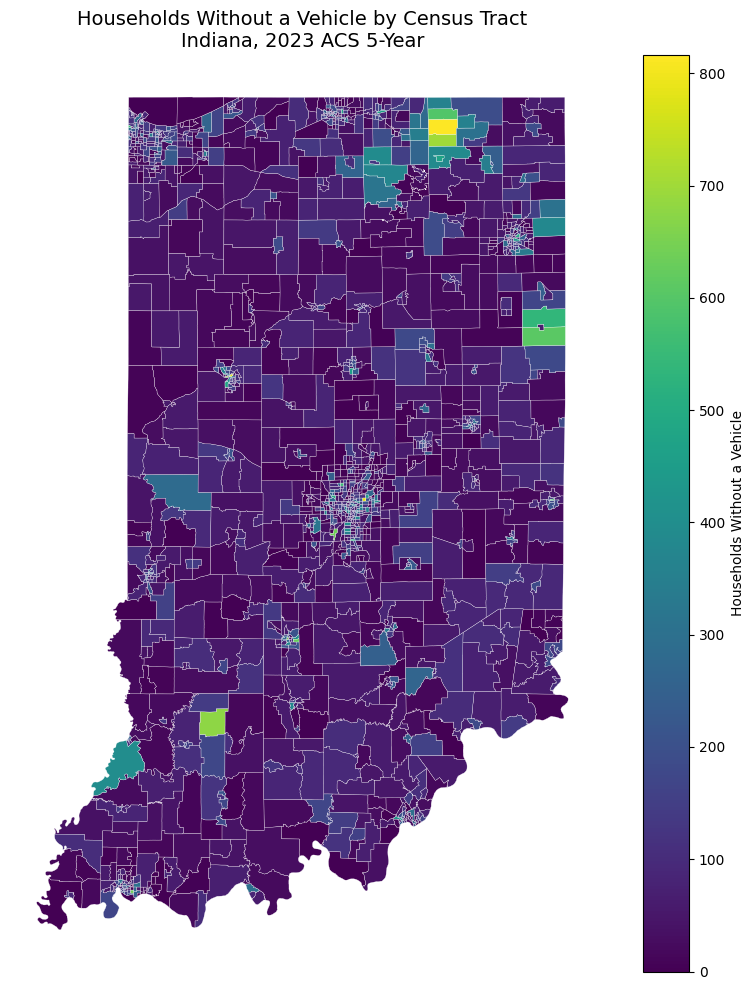

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_gdf.plot(
    column=variable,
    cmap="viridis",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": var_label, "orientation": "vertical"},
    ax=ax
)

ax.set_title(f"{var_label} by Census Tract\n{state_name}, 2023 ACS 5-Year", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4.3 — Choropleth with Explicit Color Bar

For more control over the color bar (range, label placement, formatting):

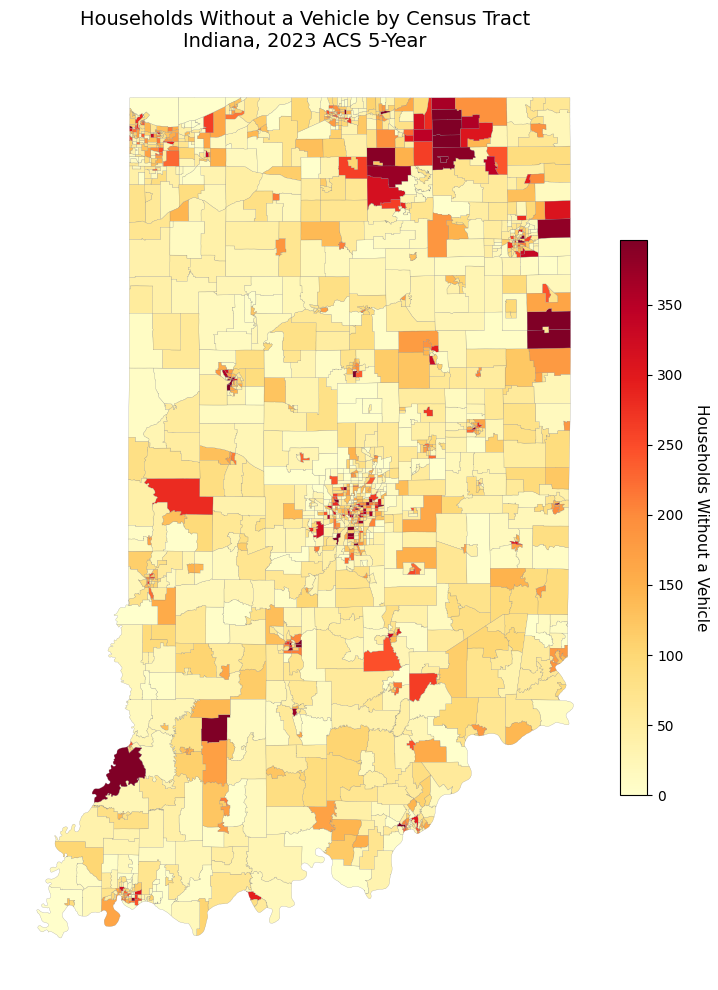

In [28]:
vmin = merged_gdf[variable].quantile(0.02)   # clip extreme outliers
vmax = merged_gdf[variable].quantile(0.98)

fig, ax = plt.subplots(figsize=(10, 10))

merged_gdf.plot(
    column=variable,
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    linewidth=0.15,
    edgecolor="grey",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

ax.set_title(f"{var_label} by Census Tract\n{state_name}, 2023 ACS 5-Year", fontsize=14)
ax.axis("off")

# Add color bar
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label(var_label, rotation=270, labelpad=18, fontsize=11)

plt.tight_layout()
plt.show()

## 4.4 — Bar Chart: Top 15 Counties

Aggregate tracts to the county level and visualize the top counties.

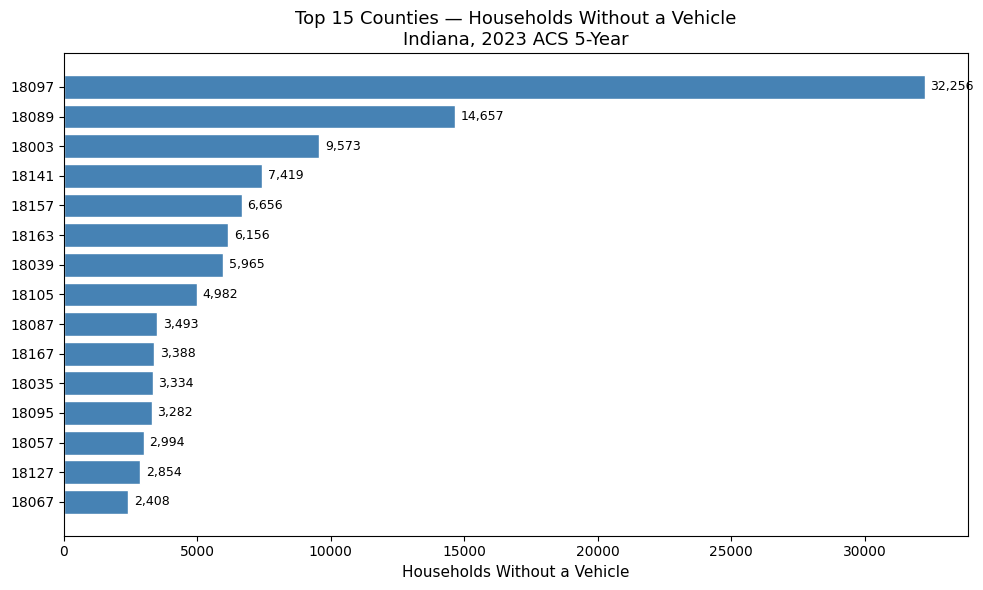

In [29]:
# Derive county FIPS and aggregate
merged_gdf["county_fips"] = merged_gdf["GEOID"].str[:5]

county_totals = (
    merged_gdf.groupby("county_fips")[variable]
    .sum()
    .reset_index()
    .rename(columns={variable: "total"})
    .sort_values("total", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    county_totals["county_fips"][::-1],
    county_totals["total"][::-1],
    color="steelblue",
    edgecolor="white"
)

ax.set_xlabel(var_label, fontsize=11)
ax.set_title(f"Top 15 Counties — {var_label}\n{state_name}, 2023 ACS 5-Year", fontsize=13)
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9)

plt.tight_layout()
plt.show()

## 4.5 — Distribution Histogram

Understand the spread of values across all tracts.

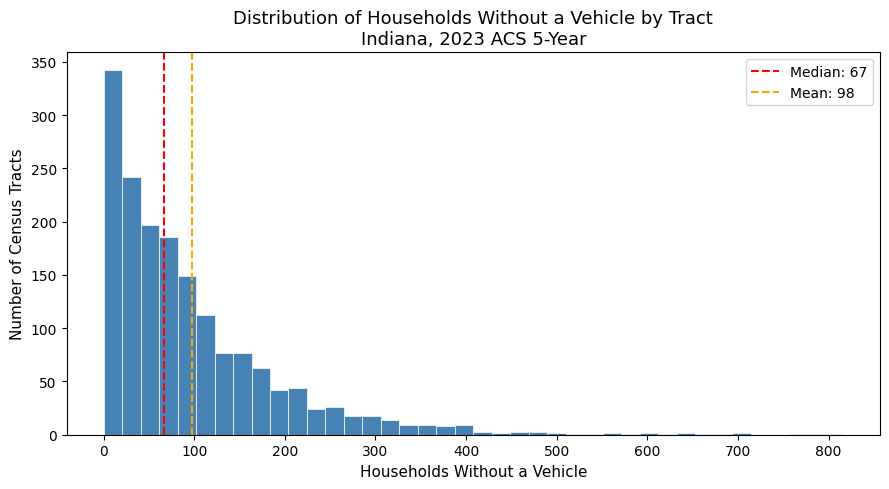

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    merged_gdf[variable].dropna(),
    bins=40,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5
)

ax.axvline(merged_gdf[variable].median(), color="red",    linestyle="--", label=f"Median: {merged_gdf[variable].median():.0f}")
ax.axvline(merged_gdf[variable].mean(),   color="orange", linestyle="--", label=f"Mean: {merged_gdf[variable].mean():.0f}")

ax.set_xlabel(var_label, fontsize=11)
ax.set_ylabel("Number of Census Tracts", fontsize=11)
ax.set_title(f"Distribution of {var_label} by Tract\n{state_name}, 2023 ACS 5-Year", fontsize=13)
ax.legend()

plt.tight_layout()
plt.show()

## 4.6 — Interpreting the Results

Use the questions below to guide your interpretation of the maps and charts:

**Spatial patterns:**
- Are high values concentrated in urban cores, suburban rings, or rural areas?
- Do the county-level patterns make sense given what you know about the region?

**Outliers:**
- Which tracts or counties have unusually high or low values?
- Could any extreme values reflect data quality issues (small populations, suppressed data)?

**Policy relevance:**
- What services, infrastructure, or interventions might be needed in high-value areas?
- How might this variable correlate with others (e.g., income, transit access)?

You can return to Part 1 and swap in a different variable code to compare.

---
## Summary

In this notebook you:
- Created choropleth maps with color bars and missing-data handling
- Built county-level bar charts to identify geographic hotspots
- Visualized the tract-level distribution with a histogram
- Practiced interpreting spatial Census patterns

**These notebooks (Parts 3 & 4) will accompany the next Carpentries lesson on Census Data Analysis.**